# Exploring the Battery Storage Environment

This notebook compares different control strategies for the battery scheduling problem:
- **Heuristic**: Simple rule — charge when cheap, discharge when expensive
- **MPC**: Model Predictive Control — solves a small optimization each step
- **LP**: Linear Programming — globally optimal with perfect foresight
- **PPO**: Reinforcement Learning agent trained via Proximal Policy Optimization
- **SAC**: Reinforcement Learning agent trained via Soft Actor-Critic (see last section)

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))
sys.path.insert(0, str(project_root / "01_workshop"))

import numpy as np
import matplotlib.pyplot as plt
from baselines import make_heuristic_policy, make_lp_policy, make_mpc_policy
from utils import run_episode, plot_episode, compute_energy_cost, LiveEvalCallback

# If you want to test your environment, set USE_SOLUTION to False and import the environment from the envs folder.
USE_SOLUTION = True
if USE_SOLUTION:
    from battery_env_solution import BatteryStorageEnv
else: 
    from envs.battery_env import BatteryStorageEnv

## 1. Environment Overview

In [2]:
# === Configuration ===
EPISODE_LENGTH = 730           # 1 month episodes (730 hours)
FORECAST_HORIZON = 4           # length of noisy forecast (in hours) 
TRAIN_FRACTION = 0.8                # fraction of episodes to use for training. 1 - TRAIN_FRACTION is used for evaluation.

# Battery properties
CAPACITY = 10.0              # kWh
MAX_CHARGE_RATE = 2.5       # kW

# Degradation settings. In this notebook we keep the setup simple by not including degradation.
ENABLE_DEGRADATION = False     # False = Level 1. In the next notebook, we will include degradation, which adds an additional challenge to the problem. 

# === Create environment ===
env = BatteryStorageEnv(
    episode_length=EPISODE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    split="train", # "train", "eval" or "all". Default is "train". 
    train_fraction=TRAIN_FRACTION,
    capacity=CAPACITY,
    max_charge_rate=MAX_CHARGE_RATE,
    enable_degradation=ENABLE_DEGRADATION
)

# Environment information
print("=== Battery Storage Environment ===")
print(f"Capacity:        {env.capacity} kWh")
print(f"Max charge rate: {env.max_charge_rate} kW")
print(f"Episode length:  {env.episode_length} steps")
print(f"Degradation:     {env.enable_degradation}")
print(f"Action space:    {env.action_space}")
print(f"Observation space: {env.observation_space}")
print(f"\nData: {env.n_episodes} total episodes, available in this split (train): {env._available_episodes}")

# You can access the data of prices and loads through env.prices and env.loads, which are loaded into numpy arrays of shape (n_episodes, episode_length).
print(f"\nPrices shape: {env.prices.shape}, Loads shape: {env.loads.shape}")
# You can also access the gobal maximum of prices and loads of the data, which can be useful for normalization, through env.max_price and env.max_load.
print(f"Max price: {env.price_max:.2f} €/kWh, Max load: {env.load_max:.3f} kWh")

=== Battery Storage Environment ===
Capacity:        10.0 kWh
Max charge rate: 2.5 kW
Episode length:  730 steps
Degradation:     False
Action space:    Box(-1.0, 1.0, (1,), float32)
Observation space: Box(0.0, 1.0, (13,), float32)

Data: 120 total episodes, available in this split (train): (0, 96)

Prices shape: (120, 730), Loads shape: (120, 730)
Max price: 0.63 €/kWh, Max load: 2.742 kWh


## 2. Baseline Policy Comparison

Compare simple policies before training any RL agent. The **baseline cost** is what you'd pay without a battery (just buying everything from the grid).

- Random: Takes random actions
- Heuristic: Charges when price < 0.5 * price_max, discharges when price > 0.5 * max_price
- MPC (Model Predictive Control): Solves a small optimization problem at each step, looking ahead H=FORECAST_HORIZON (4) steps
- LP (Linear Programming): Solves a global optimization problem with perfect foresight (not realistic, but a useful benchmark)

In [3]:
# "No battery" baseline cost: computed directly from price * load data, by multiplying the price and load arrays and summing over the episode length, then averaging over all available episodes in the split.
first_episode_in_split, last_episode_in_split = env._available_episodes
baseline_cost = np.mean(np.sum(env.prices[first_episode_in_split:last_episode_in_split] * env.loads[first_episode_in_split:last_episode_in_split], axis=1))

# Create baseline policies
policies = {
    "Random":      "random",
    "Heuristic":   make_heuristic_policy(env),
    "MPC (H=4)":   make_mpc_policy(env, horizon=FORECAST_HORIZON),
    "LP (optimal)": make_lp_policy(env),
}

# Run 10 episodes per policy and compare costs
print(f"Baseline cost (no battery): {baseline_cost:.2f} €")
print()
print("Policy Comparison (10 episodes each):")
print("=" * 65)
print(f"{'Policy':<18} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>12}")
print("-" * 65)

for name, policy in policies.items():
    episode_costs = []
    for seed in range(10): # run 10 episodes with different seeds for each policy
        data, reward = run_episode(env, policy=policy, seed=seed)
        energy_cost = compute_energy_cost(data)
        episode_costs.append(energy_cost)
    cost = np.mean(episode_costs)
    savings = baseline_cost - cost
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {cost:>11.1f} ± {np.std(episode_costs):.1f} {savings:>+11.1f} {pct:>+11.1f}%")

Baseline cost (no battery): 156.78 €

Policy Comparison (10 episodes each):
Policy                Avg Cost (€)     Savings (€)  Savings (%)
-----------------------------------------------------------------
Random                   186.5 ± 5.2       -29.8       -19.0%
Heuristic                131.7 ± 3.5       +25.1       +16.0%
MPC (H=4)                115.1 ± 2.3       +41.6       +26.6%
LP (optimal)              71.1 ± 2.2       +85.7       +54.6%


**What do these numbers tell us?**

- **Random is worse than no battery** 
- **Heuristic** saves ~10-20% with a simple price threshold rule. 
- **MPC** improves further by optimizing over a short forecast horizon, but it can only "see" 4 hours ahead.
- **LP** represents the theoretical optimum — it has perfect knowledge of all future prices. This is unrealistic in practice, but gives us an upper bound on what's achievable.

The gap between Heuristic and LP is the opportunity space for RL: can a learned policy approach LP performance using only local observations and noisy forecasts?

## 3. Visualize the Optimal Policy (LP)

Plot a single episode of LP to see how a policy behaves over time.

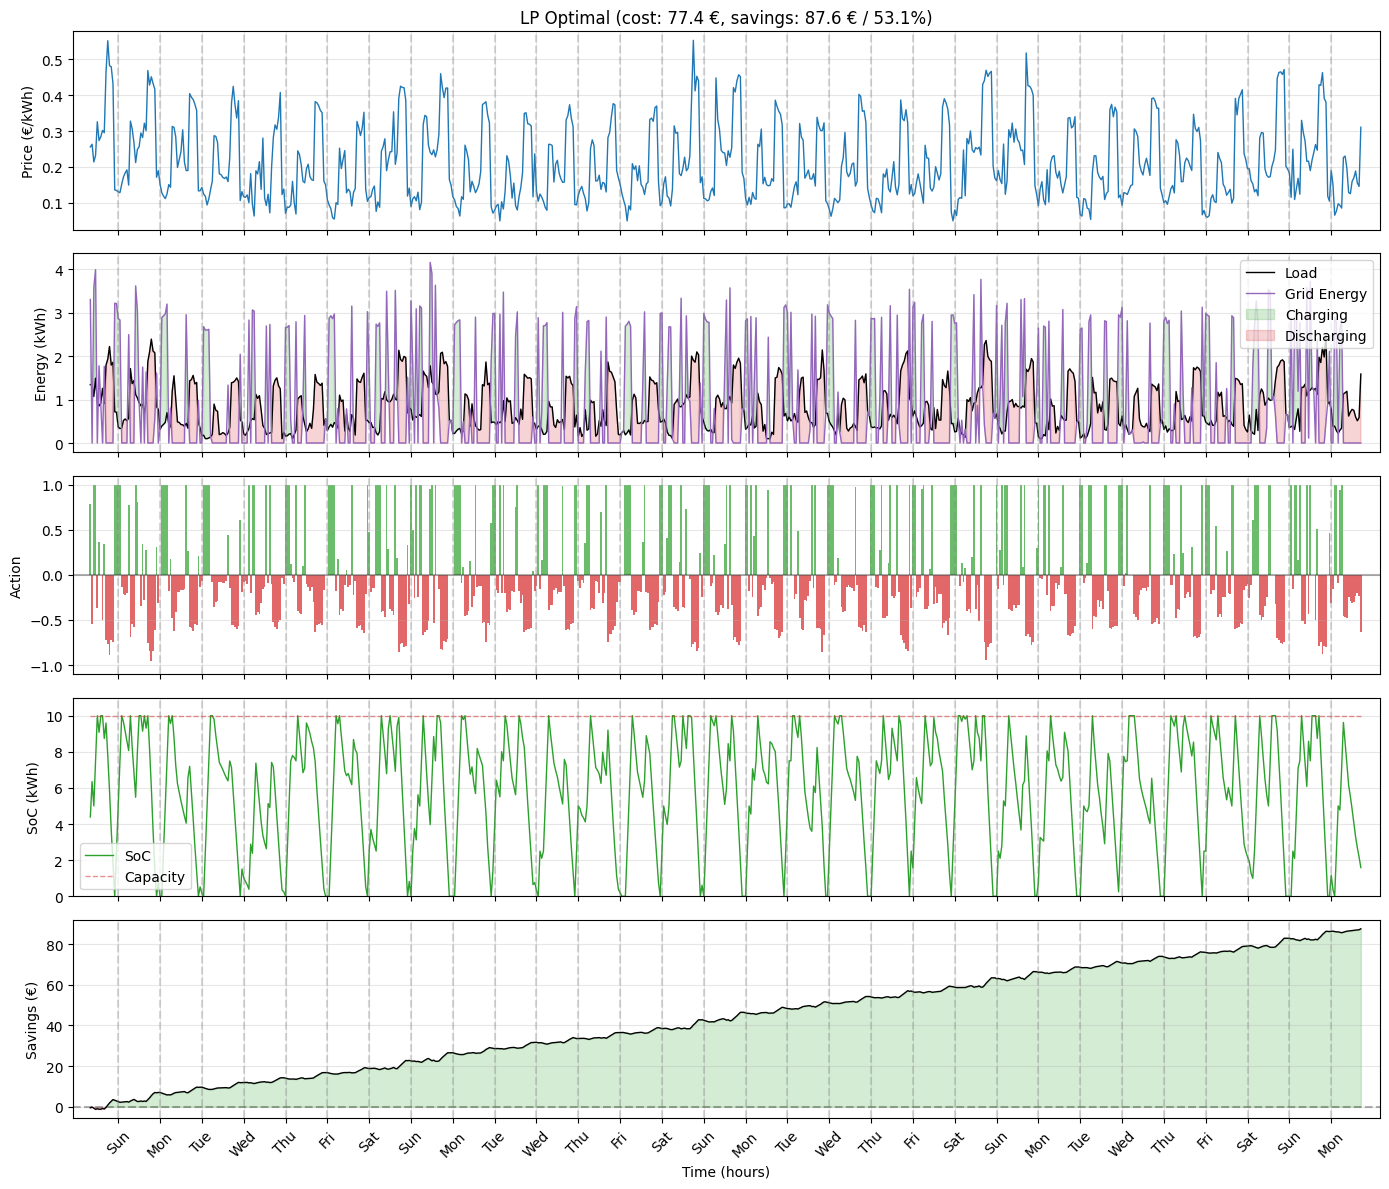

In [4]:
lp_policy = make_lp_policy(env)
data, _ = run_episode(env, policy=lp_policy, seed=42)
cost = compute_energy_cost(data)
no_battery_cost = float(np.sum(np.array(data["price"]) * np.array(data["load"])))
savings = no_battery_cost - cost

fig = plot_episode(data, f"LP Optimal (cost: {cost:.1f} €, savings: {savings:.1f} € / {100*savings/no_battery_cost:.1f}%)", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

Now let's zoom in to the first 7 days:

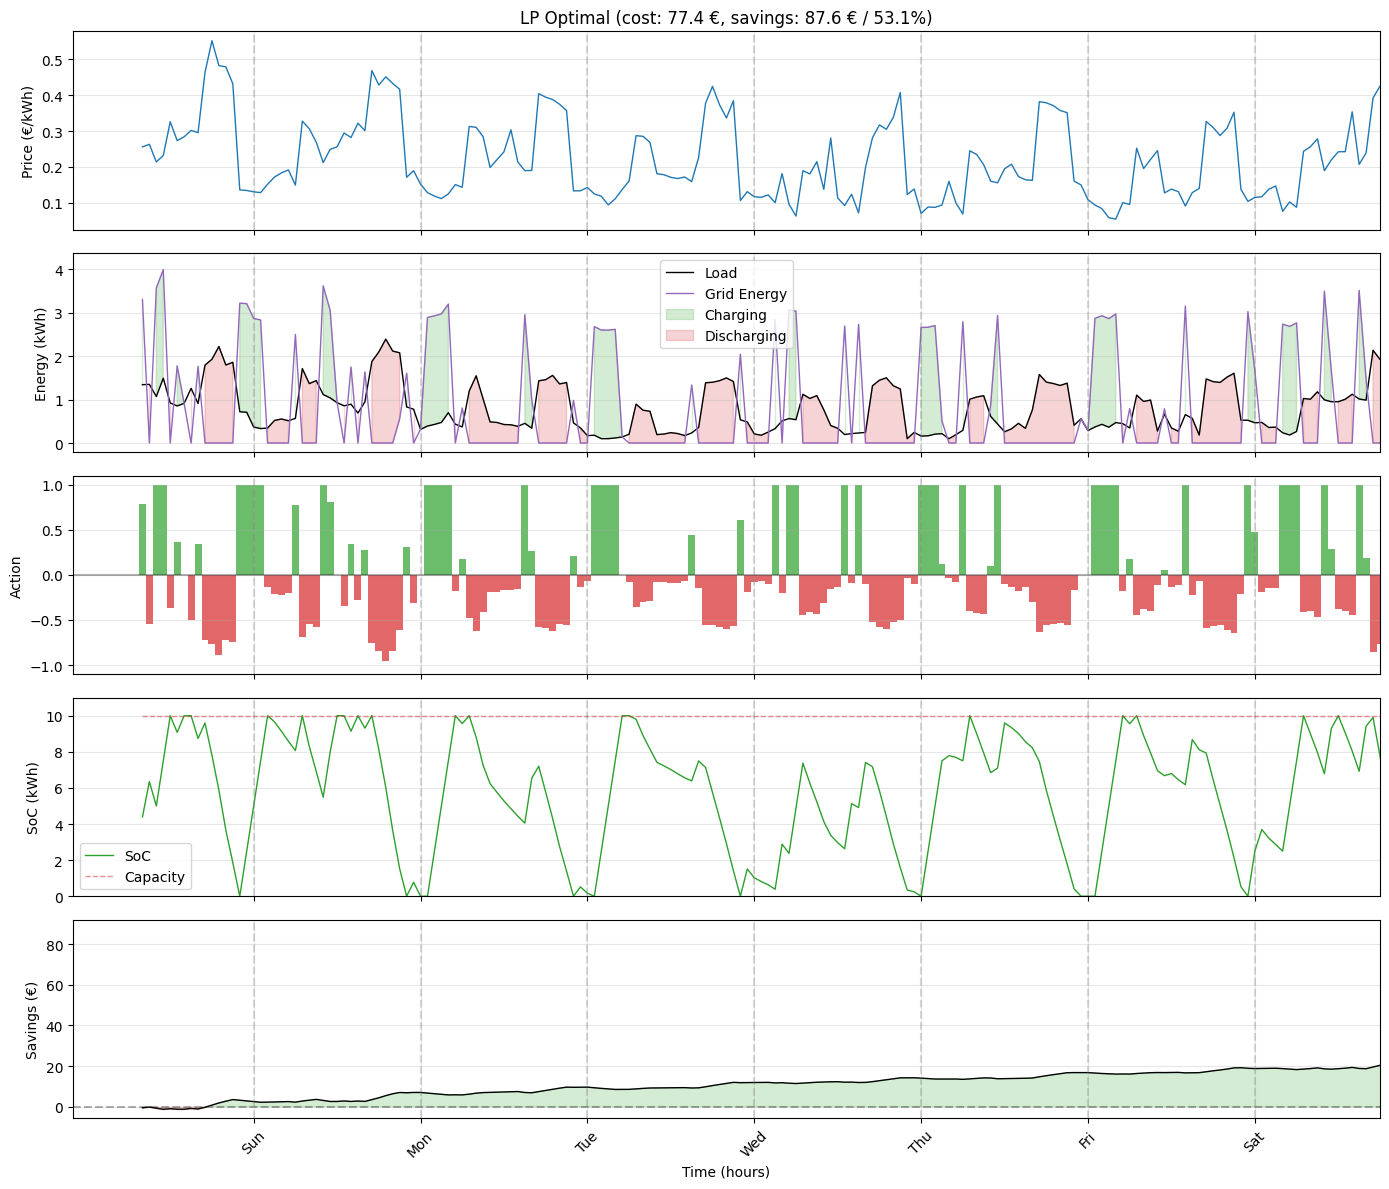

In [5]:
# lets zoom in on the first 168 hours (1 week)
hours_to_plot = 168
fig = plot_episode(data, f"LP Optimal (cost: {cost:.1f} €, savings: {savings:.1f} € / {100*savings/no_battery_cost:.1f}%)", xlim=(-10, hours_to_plot + 10))
plt.show()

**Reading the plot:** The 5 panels show (top to bottom): electricity price, household load, battery action (charge/discharge), state of charge (SoC), and cumulative savings vs. no battery.

Notice how LP charges the battery aggressively during price dips and discharges slowly during peaks.

## 4. Train PPO Agent

Stable-Baselines3 (SB3) uses **vectorized environments** to speed up training: instead of collecting data from one environment sequentially, it runs `n_envs` independent copies in parallel.

`make_vec_env` needs a **factory function** (a callable that creates a fresh environment) because each parallel worker needs its own independent instance.

In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# make_vec_env needs a factory function because it creates n_envs independent
# copies of the environment for parallel data collection (faster training)
def make_train_env():
    return BatteryStorageEnv(
        split="train",
        episode_length=EPISODE_LENGTH,
        forecast_horizon=FORECAST_HORIZON,
        train_fraction=TRAIN_FRACTION,
        capacity=CAPACITY,
        max_charge_rate=MAX_CHARGE_RATE,
        enable_degradation=ENABLE_DEGRADATION,
    )

# Vectorized training env (4 parallel workers)
train_env = make_vec_env(make_train_env, n_envs=4)

# Single evaluation env (not vectorized)
eval_env = BatteryStorageEnv(
    split="eval", # it is important to use a separate evaluation split to get an unbiased estimate of the policy's performance on unseen data.
    episode_length=EPISODE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    train_fraction=TRAIN_FRACTION,
    capacity=CAPACITY,
    max_charge_rate=MAX_CHARGE_RATE,
    enable_degradation=ENABLE_DEGRADATION,
)

print(f"Train episodes: {env._available_episodes}")
print(f"Eval episodes:  {eval_env._available_episodes}")

model = PPO("MlpPolicy", train_env, verbose=0)

Train episodes: (0, 96)
Eval episodes:  (96, 120)


We train for 1M timesteps (~1370 episodes). The `LiveEvalCallback` periodically evaluates the policy on the **eval split** (unseen data) and plots a live training curve. This takes a few minutes.

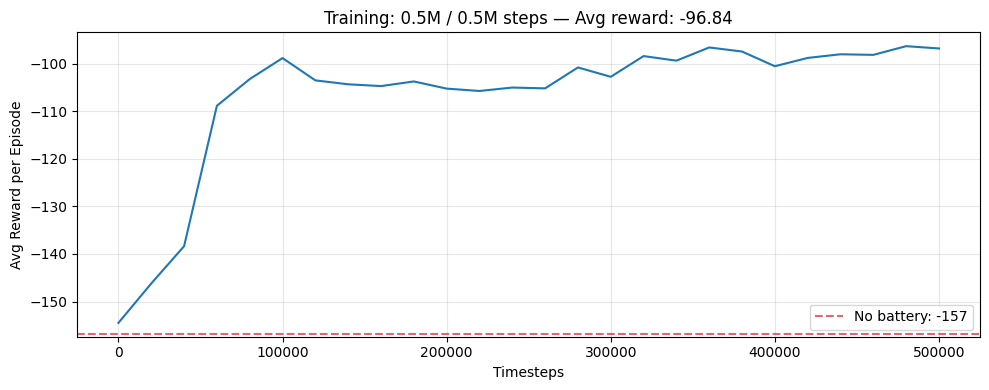

Training complete!


In [7]:
TOTAL_TIMESTEPS = int(5e5)

# Baseline cost from eval data
first_episode_in_split, last_episode_in_split = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[first_episode_in_split:last_episode_in_split] * eval_env.loads[first_episode_in_split:last_episode_in_split], axis=1))

callback = LiveEvalCallback(
    eval_env=eval_env,
    eval_freq=20_000,
    baseline_cost=baseline_cost,
)

print(f"Training PPO for {TOTAL_TIMESTEPS/1e3:.0f}k steps...")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
print("Training complete!")

## 5. Visualize Trained PPO

In [ ]:
# Wrap the trained model in a simple policy function: obs → action
# model.predict() returns a (action, state) tuple, so [0] extracts just the action.
# deterministic=True picks the most likely action instead of sampling (better for evaluation).
# The lambda gives it the same interface as our heuristic/MPC/LP policies,
# so we can pass any policy to run_episode() interchangeably.
ppo_policy = lambda obs: model.predict(obs, deterministic=True)[0]
# run the episode
data_ppo, reward_ppo = run_episode(eval_env, policy=ppo_policy, seed=42)
cost_ppo = compute_energy_cost(data_ppo)
no_battery_cost_ppo = float(np.sum(np.array(data_ppo["price"]) * np.array(data_ppo["load"])))
savings_ppo = no_battery_cost_ppo - cost_ppo

fig = plot_episode(data_ppo, f"Trained PPO Agent (cost: {cost_ppo:.1f} €, savings: {savings_ppo:.1f} € / {100*savings_ppo/no_battery_cost_ppo:.1f}%)", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

Now let's zoom into the first 7 days:

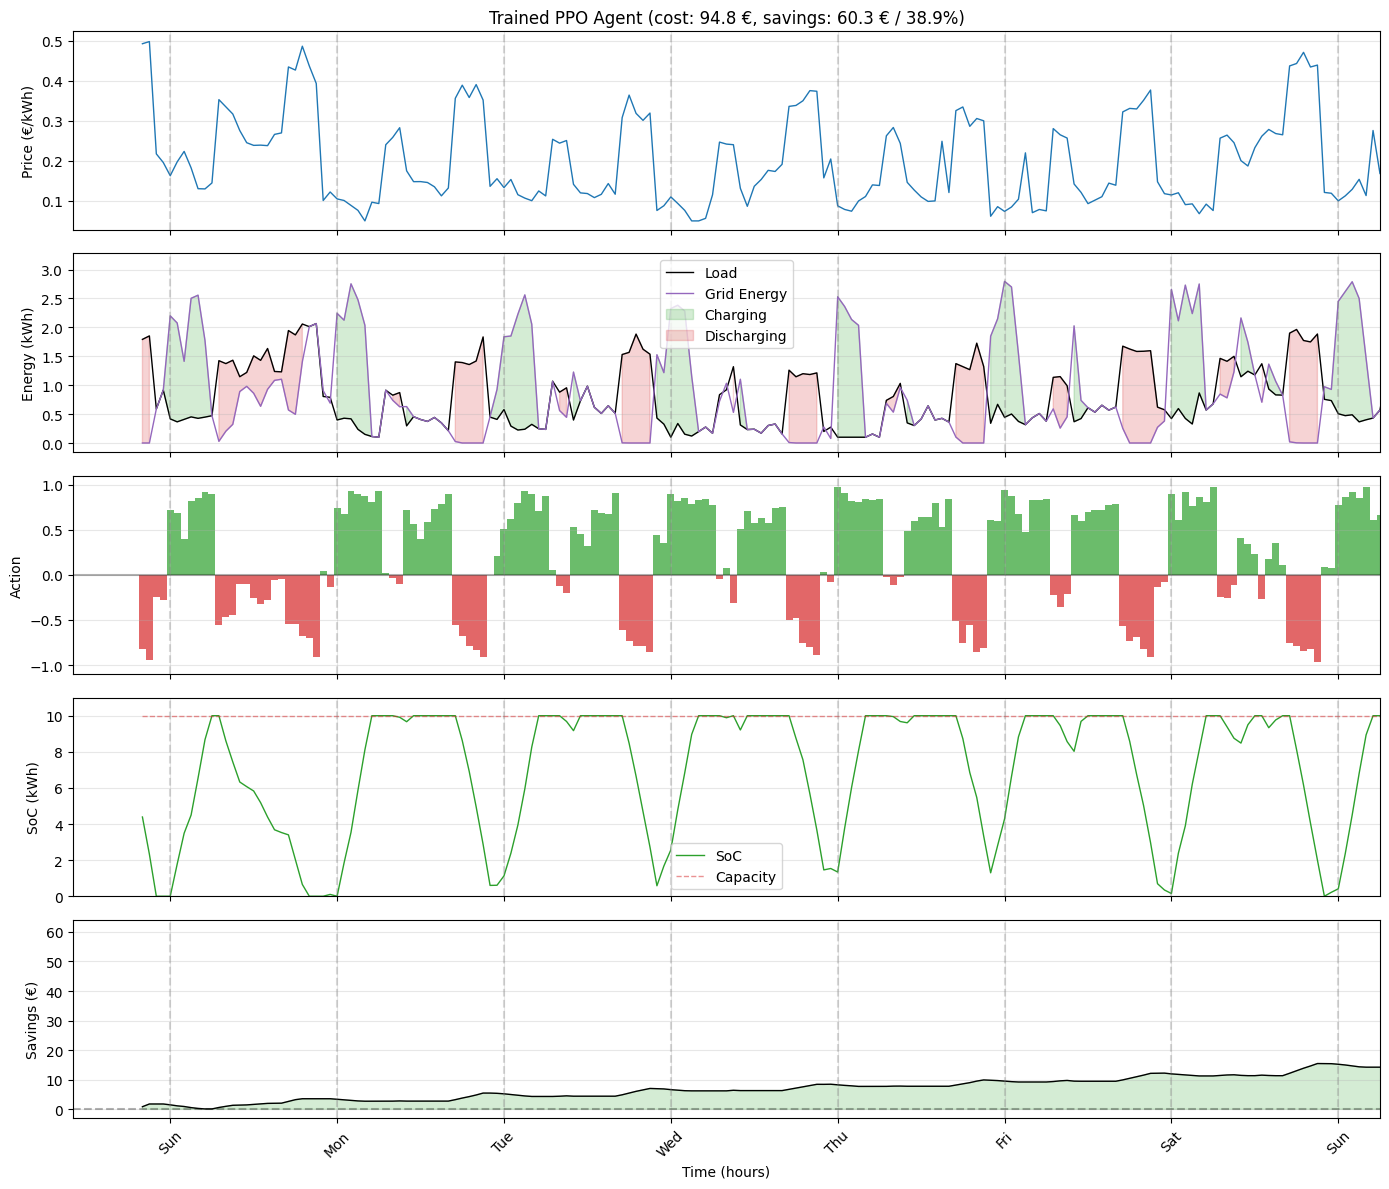

In [9]:
# lets zoom in on the first 168 hours (1 week)
hours_to_plot = 168
fig = plot_episode(data_ppo, f"Trained PPO Agent (cost: {cost_ppo:.1f} €, savings: {savings_ppo:.1f} € / {100*savings_ppo/no_battery_cost_ppo:.1f}%)", xlim=(-10, hours_to_plot + 10))
plt.show()

Compare the PPO plot to the LP plot above. PPO learns a similar charge/discharge pattern. However, PPO only sees a noisy 4-hour forecast, while LP has perfect foresight over the entire episode. 

## 6. Bonus: Soft Actor-Critic (SAC)

SAC is an **off-policy** algorithm, meaning it stores past experiences in a **replay buffer** and reuses them for training. PPO, by contrast, is on-policy — it discards data after each update. This makes SAC much more sample-efficient (it needs fewer environment interactions to learn).

SAC also maximizes a combined objective of reward + **entropy** (randomness in actions). This encourages exploration and often leads to more robust policies that generalize better.

Why SAC might be a good fit for battery scheduling:
- **Continuous actions**: SAC is designed specifically for continuous action spaces (like our [-1, 1] charge/discharge control). PPO works for both discrete and continuous, but SAC is specialized.
- **Sample efficiency**: With only 96 training episodes of 730 steps each, data is limited. SAC's replay buffer makes better use of every transition.
- **Exploration via entropy**: The battery problem has delayed rewards (charging now pays off hours later). SAC's entropy bonus helps explore different charge/discharge strategies rather than converging prematurely.

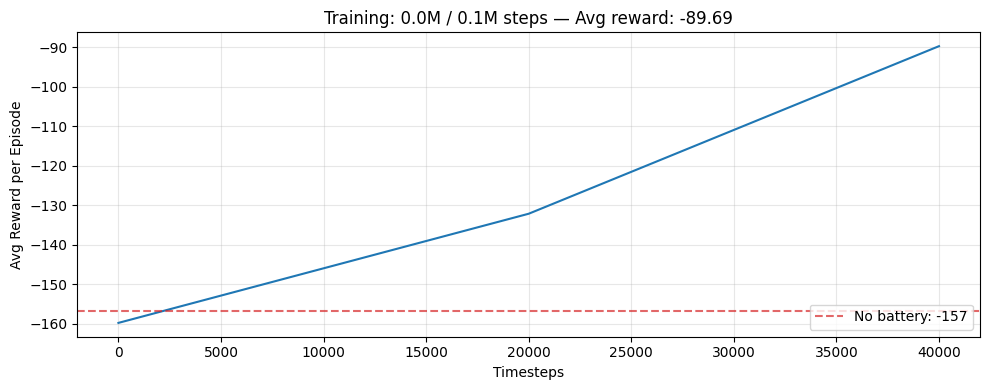

Training complete!


In [10]:
from stable_baselines3 import SAC

SAC_TIMESTEPS = int(5e4) # note that we reduced the number of timesteps compared to PPO.
# SAC is off-policy (replay buffer) so it's more sample-efficient than PPO —
# it reuses past experience, needing fewer total timesteps to converge (but more computate time).
sac_train_env = make_vec_env(make_train_env, n_envs=4)
sac_model = SAC("MlpPolicy", sac_train_env, verbose=0)

sac_callback = LiveEvalCallback(
    eval_env=eval_env,
    eval_freq=20_000,
    baseline_cost=baseline_cost,
)

print(f"Training SAC for {SAC_TIMESTEPS/1e3:.0f}k steps...")
sac_model.learn(total_timesteps=SAC_TIMESTEPS, callback=sac_callback)
print("Training complete!")

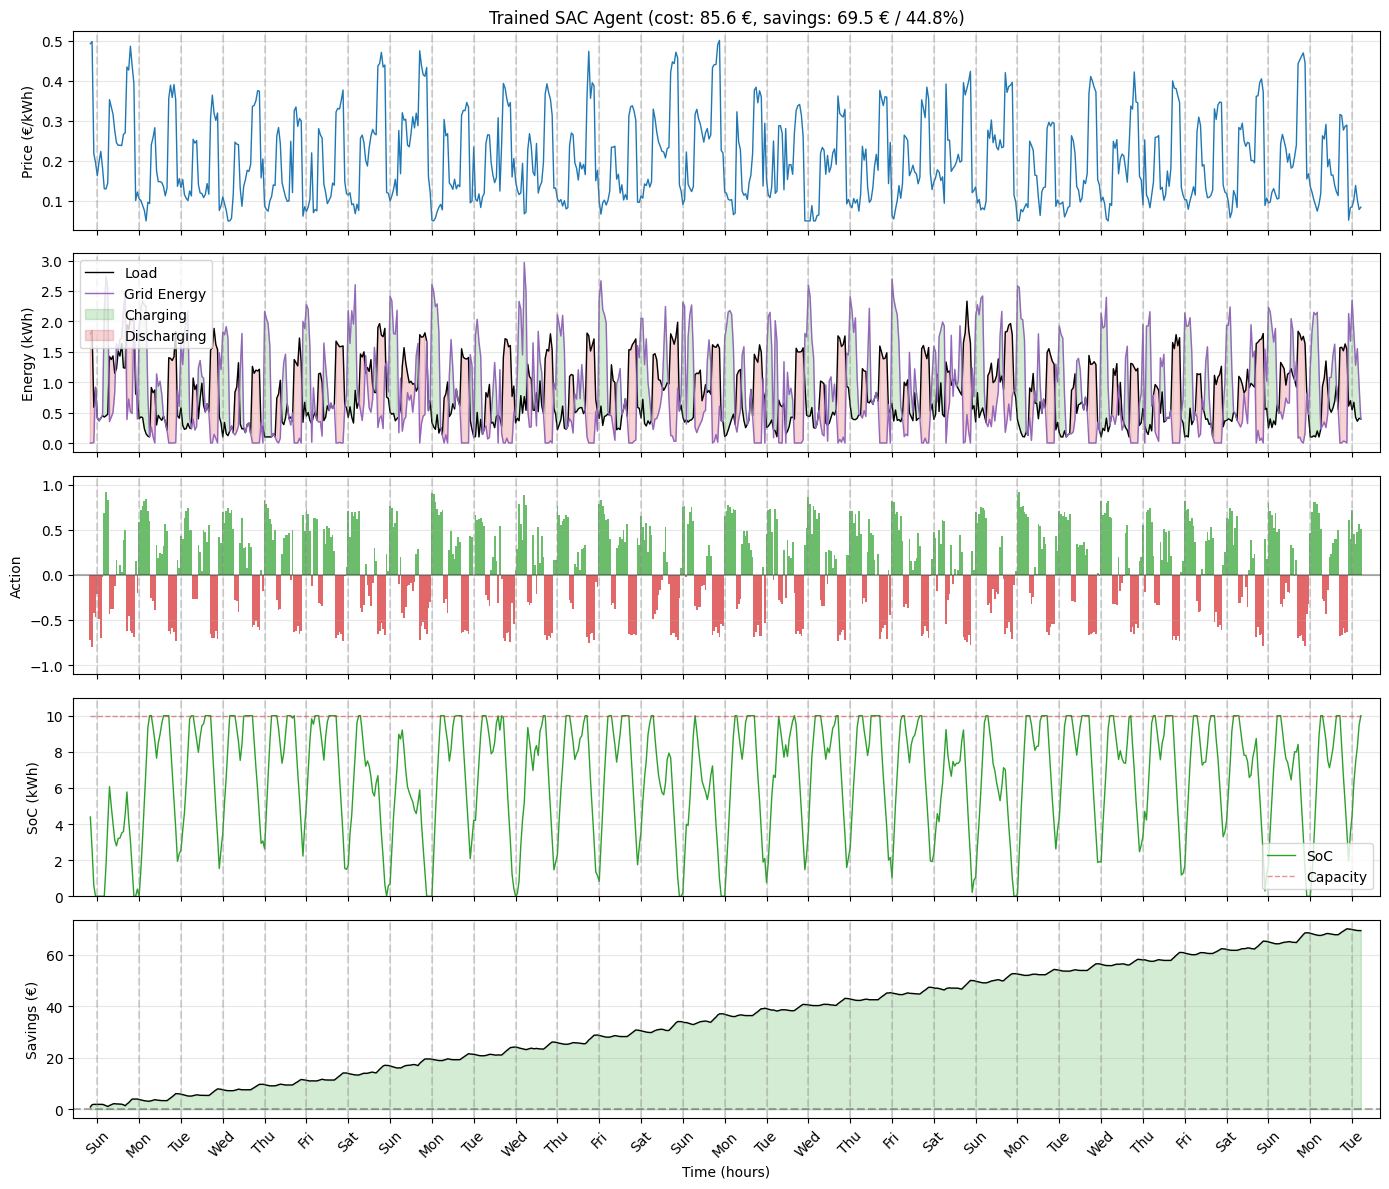

In [11]:

# Plot the trained SAC agent's performance on the evaluation environment
sac_policy = lambda obs: sac_model.predict(obs, deterministic=True)[0]
data_sac, reward_sac = run_episode(eval_env, policy=sac_policy, seed=42)
cost_sac = compute_energy_cost(data_sac)
no_battery_cost_sac = float(np.sum(np.array(data_sac["price"]) * np.array(data_sac["load"])))
savings_sac = no_battery_cost_sac - cost_sac

fig = plot_episode(data_sac, f"Trained SAC Agent (cost: {cost_sac:.1f} €, savings: {savings_sac:.1f} € / {100*savings_sac/no_battery_cost_sac:.1f}%)", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

## 7. Final Comparison (All Policies on Eval Data)

Now let's compare all policies on the **evaluation split**.

In [12]:
policies = {
    "Heuristic":    make_heuristic_policy(eval_env),
    "MPC (H=4)":    make_mpc_policy(eval_env, horizon=4),
    "LP (optimal)": make_lp_policy(eval_env),
    "PPO":          lambda obs: model.predict(obs, deterministic=True)[0],
    "SAC":          lambda obs: sac_model.predict(obs, deterministic=True)[0],
}

# Baseline from eval data
first_episode_in_split, last_episode_in_split = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[first_episode_in_split:last_episode_in_split] * eval_env.loads[first_episode_in_split:last_episode_in_split], axis=1))

# Evaluate each policy over 10 episodes
results = {}
for name, policy in policies.items():
    episode_costs = []
    for seed in range(10):
        data, reward = run_episode(eval_env, policy=policy, seed=seed)
        energy_cost = compute_energy_cost(data)
        episode_costs.append(energy_cost)
    results[name] = {"cost": np.mean(episode_costs), "std": np.std(episode_costs)}

# Print comparison table
print(f"Baseline cost (no battery): {baseline_cost:.2f} €")
print()
print("Final Comparison (10 eval episodes)")
print("=" * 65)
print(f"{'Policy':<18} {'Avg Cost (€)':>15} {'Savings (€)':>15} {'Savings (%)':>12}")
print("-" * 65)
for name, r in results.items():
    savings = baseline_cost - r["cost"]
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {r['cost']:>11.1f} ± {r['std']:.1f} {savings:>+11.1f} {pct:>+11.1f}%")

Baseline cost (no battery): 156.78 €

Final Comparison (10 eval episodes)
Policy                Avg Cost (€)     Savings (€)  Savings (%)
-----------------------------------------------------------------
Heuristic                132.1 ± 4.7       +24.7       +15.7%
MPC (H=4)                114.9 ± 4.4       +41.8       +26.7%
LP (optimal)              70.0 ± 3.6       +86.8       +55.3%
PPO                       95.0 ± 3.9       +61.8       +39.4%
SAC                       87.9 ± 4.5       +68.9       +43.9%


**Key takeaways:**

- Both RL algorithms significantly outperform Heuristic and MPC, despite having the same limited information (current state + noisy 4-hour forecast). One reason is that RL's observation includes the **hour of day**, which encodes daily price cycles that MPC can't reason about.
- **SAC outperforms PPO** while using **10x fewer timesteps** (100k vs 1M). This is the benefit of off-policy learning — SAC's replay buffer reuses past experience, making it much more sample-efficient for this continuous control problem.
- LP remains the best because it has perfect foresight over the entire episode — no online policy can beat it.

**Experiments to try:**
- Increase `SAC_TIMESTEPS` — can SAC close the gap to LP even further?
- Change `FORECAST_HORIZON` — does a longer forecast help RL more than MPC?
- In the next notebook, we enable **battery degradation**, which fundamentally changes the comparison.